In [17]:
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np

Importação do ficheiro

In [18]:
clean_output = pd.read_parquet("clean_output.parquet")

## Separação das variáveis quantitativas

In [19]:
variaveis_quantitativas = ['discounted_price', 'actual_price', 'discount_percentage', 'rating_count' , 'rating']

desc = clean_output[variaveis_quantitativas]
desc

,discounted_price,actual_price,discount_percentage,rating_count,rating
0,399.0,1099.0,64,24.269,4.2
1,199.0,349.0,43,43.994,4.0
2,199.0,1899.0,90,7.928,3.9
3,329.0,699.0,53,94.363,4.2
4,154.0,399.0,61,16.905,4.2
...,...,...,...,...,...
1460,379.0,919.0,59,1.090,4.0
1461,2280.0,3045.0,25,4.118,4.1
1462,2219.0,3080.0,28,468.000,3.6
1463,1399.0,1890.0,26,8.031,4.0


## Descrição das variáveis quantitativas

In [20]:
description_of_quantitativa_variables = desc[variaveis_quantitativas].describe().T
description_of_quantitativa_variables

,count,mean,std,min,25%,50%,75%,max
discounted_price,1351.0,3304.801754,7173.975455,39.0,349.000,899.0,2174.000,77990.0
actual_price,1351.0,5691.176625,11218.666235,39.0,899.000,1795.0,4575.000,139900.0
discount_percentage,1351.0,46.685418,21.632611,0.0,31.000,49.0,62.000,94.0
rating_count,1349.0,88.937570,188.410584,0.0,3.524,12.0,44.994,992.0
rating,1351.0,4.090674,0.300472,2.0,3.900,4.1,4.300,5.0


### Moda de cada uma das variáveis quantitativas

In [21]:
description_of_quantitativa_variables['moda'] = desc[variaveis_quantitativas].mode().iloc[0]

In [22]:
description_of_quantitativa_variables

,count,mean,std,min,25%,50%,75%,max,moda
discounted_price,1351.0,3304.801754,7173.975455,39.0,349.000,899.0,2174.000,77990.0,299.0
actual_price,1351.0,5691.176625,11218.666235,39.0,899.000,1795.0,4575.000,139900.0,999.0
discount_percentage,1351.0,46.685418,21.632611,0.0,31.000,49.0,62.000,94.0,50.0
rating_count,1349.0,88.937570,188.410584,0.0,3.524,12.0,44.994,992.0,0.0
rating,1351.0,4.090674,0.300472,2.0,3.900,4.1,4.300,5.0,4.1


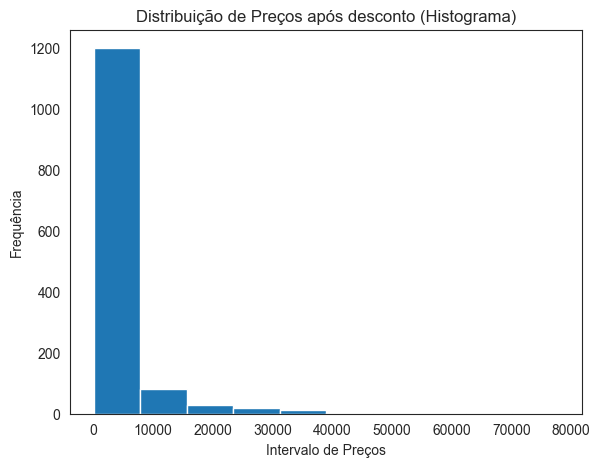

In [23]:

fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

axes.hist(clean_output['discounted_price'].sort_values())

axes.set_xlabel('Intervalo de Preços')
axes.set_ylabel('Frequência')
axes.set_title('Distribuição de Preços após desconto (Histograma)')

plt.show()


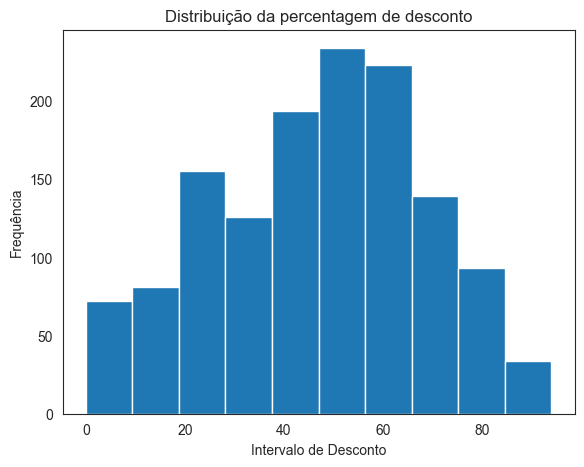

In [24]:
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

axes.hist(clean_output['discount_percentage'].sort_values(),)

axes.set_xlabel('Intervalo de Desconto')
axes.set_ylabel('Frequência')
axes.set_title('Distribuição da percentagem de desconto')

plt.show()


### Distribuição da variável rating

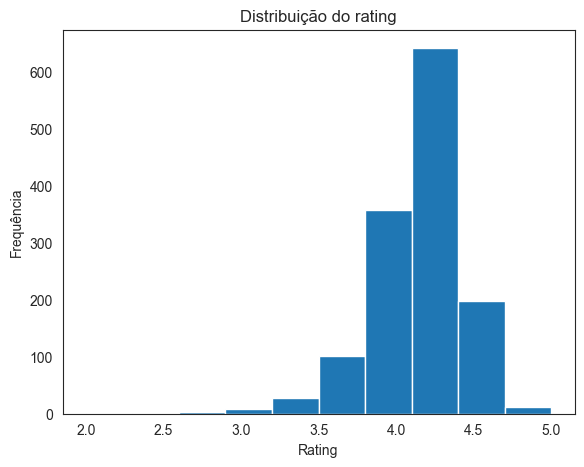

In [26]:
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])

axes.hist(clean_output['rating'].sort_values(),)

axes.set_xlabel('Rating')
axes.set_ylabel('Frequência')
axes.set_title('Distribuição do rating')

plt.show()

### Relação entre as variáveis rating count e rating
Existem outliers que podem ser analisados

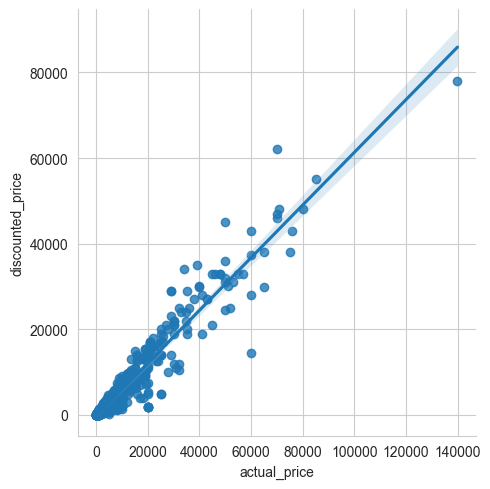

In [27]:
sns.set_style('whitegrid')
sns.lmplot(x="actual_price", y="discounted_price", data=desc)


### BoxPlots

<Axes: ylabel='rating'>

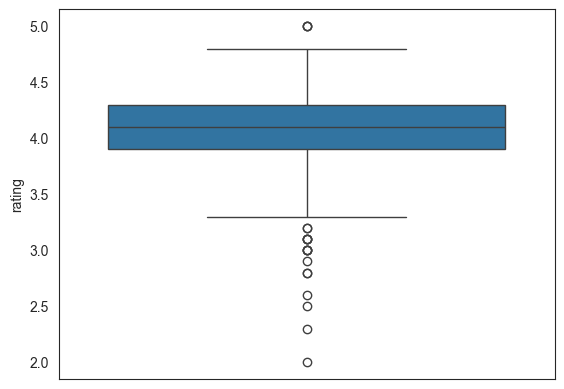

In [28]:
sns.set_style('white')
sns.boxplot(desc['rating'])

## Heatmap

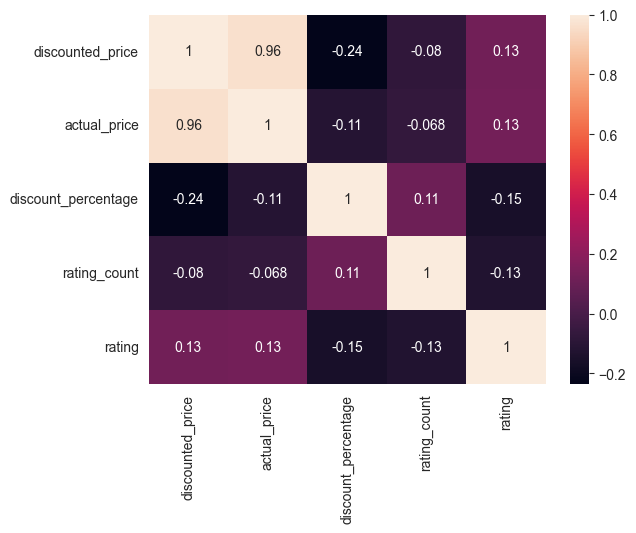

In [29]:
# Calculate correlations
corr = desc.corr()
 
# Heatmap
sns.heatmap(corr, annot=True);

## Análise entre as variáveis quantitativas

### Separação das Variáveis Qualitativas

In [30]:
variaveis_qualitatives = ['product_id',	'product_name', 'category', 'about_product']

desc1 = clean_output[variaveis_qualitatives]

desc1.describe().T

,count,unique,top,freq
product_id,1351,1351,B07JW9H4J1,1
product_name,1351,1337,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5
category,1351,211,Computers&Accessories|Accessories&Peripherals|...,161
about_product,1351,1290,Bluetooth Calling- Wave Call comes with a prem...,4


### Frequências absoluta, relativa, absoluta acomulativa e relativa absoluta relativa para as variáveis quantitativas

In [31]:
var = 'category' 
freq = desc1[var].value_counts().to_frame('Absoluta') 
freq['Relativa'] = freq['Absoluta'] / len(desc1) 
freq['Abs Acum'] = freq['Absoluta'].cumsum() 
freq['Rel Acum'] = freq['Relativa'].cumsum() 
freq.round(3)

,Absoluta,Relativa,Abs Acum,Rel Acum
category,,,,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,161,0.119,161,0.119
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,68,0.050,229,0.170
Electronics|WearableTechnology|SmartWatches,62,0.046,291,0.215
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",60,0.044,351,0.260
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",51,0.038,402,0.298
...,...,...,...,...
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers,1,0.001,1347,0.997
"Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories",1,0.001,1348,0.998
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|StandMixers,1,0.001,1349,0.999


In [15]:
freq.head(50)

,Absoluta,Relativa,Abs Acum,Rel Acum
category,,,,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,161,0.119171,161,0.119171
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,68,0.050333,229,0.169504
Electronics|WearableTechnology|SmartWatches,62,0.045892,291,0.215396
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",60,0.044412,351,0.259808
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",51,0.037750,402,0.297557
"Electronics|HomeTheater,TV&Video|Accessories|RemoteControls",49,0.036269,451,0.333827
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders,27,0.019985,478,0.353812
"Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice",24,0.017765,502,0.371577
"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Irons,Steamers&Accessories|Irons|DryIrons",24,0.017765,526,0.389341


### Tabela de contingência (cruzamento entre variáveis) 

In [16]:
desc1.isnull().sum().to_frame("Missing Values") 

,Missing Values
product_id,0
product_name,0
category,0
about_product,0
